<a href="https://colab.research.google.com/github/EcTrailblazers/python-data-projects/blob/main/12_world_bank_api_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

# Indicators to fetch:
# NY.GDP.MKTP.KD.ZG = GDP growth (annual %)
# Countries: IND (India), BRA (Brazil), IDN (Indonesia), ZAF (South Africa)
countries = ["IND", "BRA", "IDN", "ZAF"]
indicator = "NY.GDP.MKTP.KD.ZG"
start_year = 2014
end_year = 2024

api_url = f"https://api.worldbank.org/v2/country/{';'.join(countries)}/indicator/{indicator}"
params = {
    "date": f"{start_year}:{end_year}",
    "format": "json",
    "per_page": 1000,
}

response = requests.get(api_url, params=params)

if response.status_code == 200:
    api_payload = response.json()
    print(f"API request successful. Total records fetched: {len(api_payload[1])}")
else:
    raise ConnectionError(f"API request failed with status code {response.status_code}")

API request successful. Total records fetched: 44


In [2]:
records = api_payload[1]

parsed_data = []
for item in records:
    parsed_data.append(
        {
            "Country_Code": item["countryiso3code"],
            "Country": item["country"]["value"],
            "Year": int(item["date"]),
            "GDP_Growth_%": (
                round(item["value"], 2) if item["value"] is not None else np.nan
            ),
        }
    )

df_macro = pd.DataFrame(parsed_data)

# Sort chronologically
df_macro = df_macro.sort_values(
    by=["Country_Code", "Year"]
).reset_index(drop=True)

print("--- Parsed API Data Preview ---")
print(df_macro.head(10))

--- Parsed API Data Preview ---
  Country_Code Country  Year  GDP_Growth_%
0          BRA  Brazil  2014          0.50
1          BRA  Brazil  2015         -3.55
2          BRA  Brazil  2016         -3.28
3          BRA  Brazil  2017          1.32
4          BRA  Brazil  2018          1.78
5          BRA  Brazil  2019          1.22
6          BRA  Brazil  2020         -3.28
7          BRA  Brazil  2021          4.76
8          BRA  Brazil  2022          3.02
9          BRA  Brazil  2023          3.24


In [3]:
# Pivot to format Years as rows and Countries as columns
df_growth_pivot = df_macro.pivot(
    index="Year", columns="Country", values="GDP_Growth_%"
)

# Compute long-term average growth rates (CAGR proxy)
growth_summary = pd.DataFrame(
    {
        "Mean_Annual_Growth_%": df_growth_pivot.mean(),
        "Median_Growth_%": df_growth_pivot.median(),
        "Std_Dev (Volatility)": df_growth_pivot.std(),
        "Min_Growth_% (COVID trough)": df_growth_pivot.min(),
        "Max_Growth_%": df_growth_pivot.max(),
    }
).round(2)

print("--- Emerging Economies Growth Trajectory ---")
print(df_growth_pivot.tail(5))

print("\n--- 10-Year Macro Performance Summary ---")
print(growth_summary)

--- Emerging Economies Growth Trajectory ---
Country  Brazil  India  Indonesia  South Africa
Year                                           
2020      -3.28  -5.78      -2.07         -6.17
2021       4.76   9.69       3.70          4.86
2022       3.02   7.61       5.31          2.06
2023       3.24   7.21       5.05          0.81
2024       3.42   7.10       5.03          0.53

--- 10-Year Macro Performance Summary ---
              Mean_Annual_Growth_%  Median_Growth_%  Std_Dev (Volatility)  \
Country                                                                     
Brazil                        0.83             1.32                  2.95   
India                         6.06             7.21                  4.17   
Indonesia                     4.29             5.03                  2.15   
South Africa                  0.77             1.16                  2.61   

              Min_Growth_% (COVID trough)  Max_Growth_%  
Country                                                

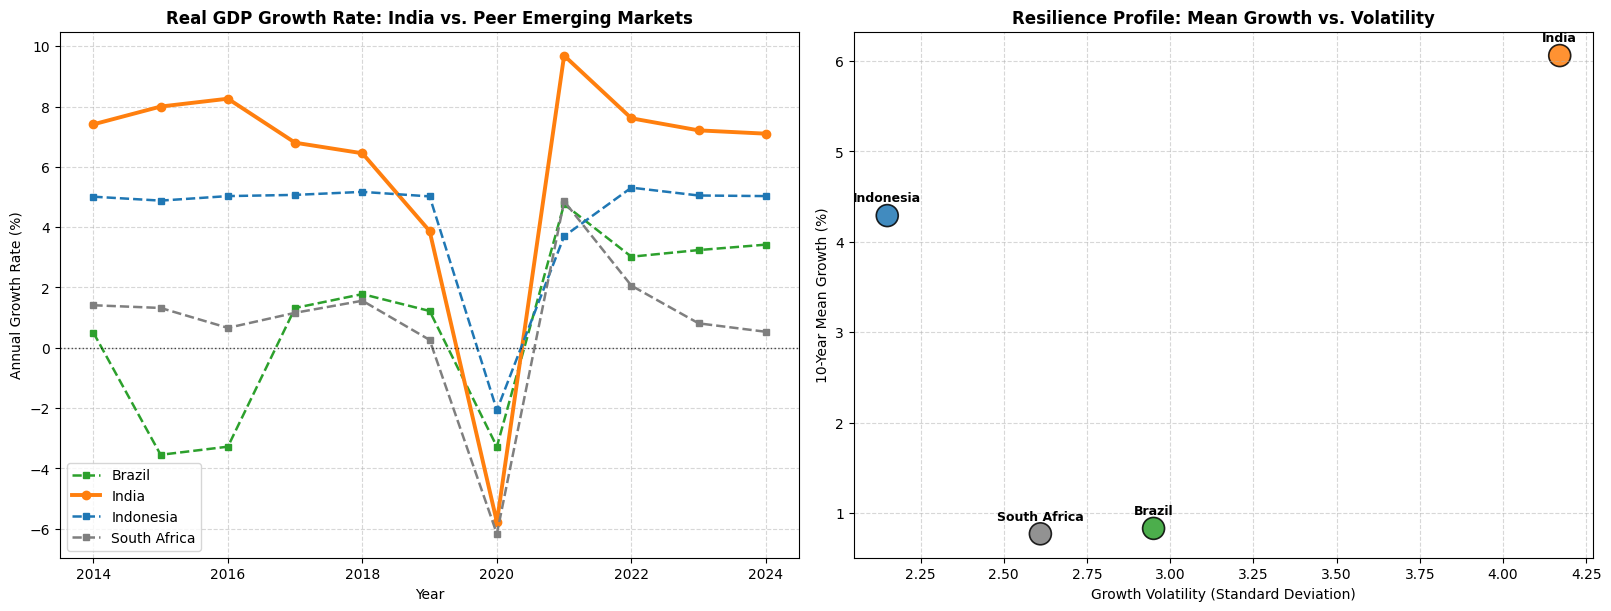

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), layout="constrained")

# --- Chart 1: GDP Growth Trajectory (2014-2024) ---
country_palette = {
    "India": "#ff7f0e",
    "Brazil": "#2ca02c",
    "Indonesia": "#1f77b4",
    "South Africa": "#7f7f7f",
}

for country in df_growth_pivot.columns:
    is_india = country == "India"
    ax1.plot(
        df_growth_pivot.index,
        df_growth_pivot[country],
        label=country,
        color=country_palette.get(country, "#333333"),
        linewidth=2.8 if is_india else 1.8,
        linestyle="-" if is_india else "--",
        marker="o" if is_india else "s",
        markersize=6 if is_india else 4,
    )

ax1.axhline(0, color="black", linestyle=":", linewidth=1, alpha=0.7)
ax1.set_title("Real GDP Growth Rate: India vs. Peer Emerging Markets", fontsize=12, weight="bold")
ax1.set_xlabel("Year")
ax1.set_ylabel("Annual Growth Rate (%)")
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(loc="lower left")

# --- Chart 2: 10-Year Average Growth vs. Volatility Scatter ---
ax2.scatter(
    growth_summary["Std_Dev (Volatility)"],
    growth_summary["Mean_Annual_Growth_%"],
    s=250,
    color=[
        country_palette.get(c, "#1f77b4") for c in growth_summary.index
    ],
    edgecolor="black",
    linewidth=1.2,
    alpha=0.85,
)

for country, row in growth_summary.iterrows():
    ax2.annotate(
        country,
        (row["Std_Dev (Volatility)"], row["Mean_Annual_Growth_%"]),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=9,
        weight="bold",
    )

ax2.set_title("Resilience Profile: Mean Growth vs. Volatility", fontsize=12, weight="bold")
ax2.set_xlabel("Growth Volatility (Standard Deviation)")
ax2.set_ylabel("10-Year Mean Growth (%)")
ax2.grid(True, linestyle="--", alpha=0.5)

plt.show()